# Notebook 02 — Analyse Emotionnelle Bilingue (MLP PyTorch)

## Objectif
Entraîner un modèle MLP bilingue (FR/EN) capable de classifier les émotions d'un texte en **7 classes** :
`joie`, `colere`, `tristesse`, `peur`, `degout`, `surprise`, `neutre`.

## Datasets
- **EN** : Twitter Emotion Dataset (20 000 tweets, 6 classes : sadness/joy/love/anger/fear/surprise)
- **FR** : Dataset émotions FR (14 000 textes, 7 classes : joie/colere/tristesse/peur/degout/surprise/neutre)

## Mapping des labels EN → FR
| EN (original) | FR (cible) | Justification |
|---|---|---|
| joy (1) | joie | Equivalence directe |
| anger (3) | colere | Equivalence directe |
| sadness (0) | tristesse | Equivalence directe |
| fear (4) | peur | Equivalence directe |
| surprise (5) | surprise | Equivalence directe |
| **love (2)** | **joie** | Emotion positive la plus proche — choix assumé |

Les classes `degout` et `neutre` n'ont **pas d'équivalent** dans le dataset EN. Elles sont entraînées exclusivement sur les données FR. C'est une limite documentée : le modèle sera moins fiable sur ces deux classes pour des textes anglais.

## Contrat d'interface (Phase 2)
Le modèle doit exposer un `predict_proba()` retournant un vecteur de **7 probabilités** par texte, utilisable comme features dans le détecteur de fake news bilingue.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import LabelEncoder

plt.style.use('seaborn-v0_8-whitegrid')

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'PyTorch: {torch.__version__}')
print(f'Device: {device}')
print('Imports OK')

PyTorch: 2.10.0
Device: mps
Imports OK


---
## PARTIE 1 — Chargement et fusion des datasets bilingues

In [2]:
# === Dataset EN (Twitter Emotion) ===
df_en_train = pd.read_csv('../data/training/training.csv')
df_en_val = pd.read_csv('../data/training/validation.csv')
df_en_test = pd.read_csv('../data/training/test.csv')

print('=== Dataset EN ===')
print(f'  Train: {len(df_en_train)}, Val: {len(df_en_val)}, Test: {len(df_en_test)}')
print(f'  Labels EN: {sorted(df_en_train["label"].unique())}')
print()

# Mapping EN (numeric) -> FR (string)
EN_TO_FR = {
    0: 'tristesse',
    1: 'joie',
    2: 'joie',       # love -> joie (choix assume)
    3: 'colere',
    4: 'peur',
    5: 'surprise',
}

for df in [df_en_train, df_en_val, df_en_test]:
    df['label'] = df['label'].map(EN_TO_FR)
    df['language'] = 'en'

print(f'  Labels EN apres mapping: {df_en_train["label"].value_counts().to_dict()}')
print(f'  Note: love ({(pd.read_csv("../data/training/training.csv")["label"]==2).sum()} tweets) fusionne dans joie')
print()

# === Dataset FR ===
df_fr_train = pd.read_csv('../data/training/train.csv')
df_fr_val = pd.read_csv('../data/training/validationfr.csv')
df_fr_test = pd.read_csv('../data/training/testfr.csv')

for df in [df_fr_train, df_fr_val, df_fr_test]:
    df['language'] = 'fr'

print('=== Dataset FR ===')
print(f'  Train: {len(df_fr_train)}, Val: {len(df_fr_val)}, Test: {len(df_fr_test)}')
print(f'  Labels FR: {df_fr_train["label"].value_counts().to_dict()}')
print()

# === Fusion bilingue ===
df_train = pd.concat([df_en_train, df_fr_train], ignore_index=True)
df_val = pd.concat([df_en_val, df_fr_val], ignore_index=True)
df_test = pd.concat([df_en_test, df_fr_test], ignore_index=True)

# Shuffle train
df_train = df_train.sample(frac=1, random_state=42).reset_index(drop=True)

print('=== Dataset bilingue fusionne ===')
print(f'  Train: {len(df_train)} (EN: {(df_train["language"]=="en").sum()}, FR: {(df_train["language"]=="fr").sum()})')
print(f'  Val:   {len(df_val)} (EN: {(df_val["language"]=="en").sum()}, FR: {(df_val["language"]=="fr").sum()})')
print(f'  Test:  {len(df_test)} (EN: {(df_test["language"]=="en").sum()}, FR: {(df_test["language"]=="fr").sum()})')
print(f'\n  Distribution labels (train):')
for label, count in df_train['label'].value_counts().sort_index().items():
    print(f'    {label:12s}: {count:5d}')

=== Dataset EN ===
  Train: 16000, Val: 2000, Test: 2000
  Labels EN: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

  Labels EN apres mapping: {'joie': 6666, 'tristesse': 4666, 'colere': 2159, 'peur': 1937, 'surprise': 572}
  Note: love (1304 tweets) fusionne dans joie

=== Dataset FR ===
  Train: 9800, Val: 2100, Test: 2100
  Labels FR: {'joie': 1400, 'neutre': 1400, 'peur': 1400, 'colere': 1400, 'tristesse': 1400, 'degout': 1400, 'surprise': 1400}

=== Dataset bilingue fusionne ===
  Train: 25800 (EN: 16000, FR: 9800)
  Val:   4100 (EN: 2000, FR: 2100)
  Test:  4100 (EN: 2000, FR: 2100)

  Distribution labels (train):
    colere      :  3559
    degout      :  1400
    joie        :  8066
    neutre      :  1400
    peur        :  3337
    surprise    :  1972
    tristesse   :  6066


---
## PARTIE 2 — Preparation des donnees et tokenisation bilingue

In [3]:
# Parametres
VOCAB_SIZE = 25000
MAX_LENGTH = 60
BATCH_SIZE = 32

# Label encoding (7 classes)
LABEL_ORDER = ['colere', 'degout', 'joie', 'neutre', 'peur', 'surprise', 'tristesse']
le = LabelEncoder()
le.fit(LABEL_ORDER)

y_train = le.transform(df_train['label'].values)
y_val = le.transform(df_val['label'].values)
y_test = le.transform(df_test['label'].values)

print(f'Label encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}')
print(f'Nombre de classes: {len(le.classes_)}')
print()

# === Tokenizer maison (equivalent Keras Tokenizer) ===
def build_vocab(texts, max_words):
    """Construit un vocabulaire word->index a partir des textes."""
    counter = Counter()
    for text in texts:
        tokens = str(text).lower().split()
        counter.update(tokens)
    # Index 0 = padding, 1 = OOV
    vocab = {'<PAD>': 0, '<OOV>': 1}
    for word, _ in counter.most_common(max_words - 2):
        vocab[word] = len(vocab)
    return vocab

def texts_to_sequences(texts, vocab, max_len):
    """Convertit les textes en sequences d'indices paddes."""
    oov_idx = vocab['<OOV>']
    sequences = []
    for text in texts:
        tokens = str(text).lower().split()
        seq = [vocab.get(t, oov_idx) for t in tokens[:max_len]]
        # Padding post
        seq = seq + [0] * (max_len - len(seq))
        sequences.append(seq)
    return np.array(sequences, dtype=np.int64)

# Build vocab sur train uniquement
vocab = build_vocab(df_train['text'].values, VOCAB_SIZE)

X_train = texts_to_sequences(df_train['text'].values, vocab, MAX_LENGTH)
X_val = texts_to_sequences(df_val['text'].values, vocab, MAX_LENGTH)
X_test = texts_to_sequences(df_test['text'].values, vocab, MAX_LENGTH)

print(f'Vocabulaire: {len(vocab)} tokens')
print(f'X_train shape: {X_train.shape}')
print(f'X_val shape:   {X_val.shape}')
print(f'X_test shape:  {X_test.shape}')

# DataLoaders PyTorch
train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train).long())
val_ds = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val).long())
test_ds = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test).long())

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

print(f'\nExemple FR: "{df_train["text"].iloc[0][:80]}..."')
print(f'  -> sequence: {X_train[0][:10]}...')
print(f'  -> label: {df_train["label"].iloc[0]} ({y_train[0]})')

Label encoding: {np.str_('colere'): np.int64(0), np.str_('degout'): np.int64(1), np.str_('joie'): np.int64(2), np.str_('neutre'): np.int64(3), np.str_('peur'): np.int64(4), np.str_('surprise'): np.int64(5), np.str_('tristesse'): np.int64(6)}
Nombre de classes: 7

Vocabulaire: 25000 tokens
X_train shape: (25800, 60)
X_val shape:   (4100, 60)
X_test shape:  (4100, 60)

Exemple FR: "i paused feeling that what would come next would be fake..."
  -> sequence: [   2 5963    9   10   72   89  230  368   89   34]...
  -> label: tristesse (6)


---
## PARTIE 3 — Entrainement du MLP bilingue

In [4]:
class EmotionMLP(nn.Module):
    """MLP bilingue pour classification d'emotions.
    Architecture: Embedding -> GlobalAveragePooling -> Dense(48) -> Dense(24) -> Dense(7)
    """
    def __init__(self, vocab_size, embed_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.fc1 = nn.Linear(embed_dim, 48)
        self.drop1 = nn.Dropout(0.4)
        self.fc2 = nn.Linear(48, 24)
        self.drop2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(24, num_classes)

    def forward(self, x):
        x = self.embedding(x)          # (batch, seq_len, embed_dim)
        x = x.mean(dim=1)              # Global Average Pooling -> (batch, embed_dim)
        x = torch.relu(self.fc1(x))
        x = self.drop1(x)
        x = torch.relu(self.fc2(x))
        x = self.drop2(x)
        x = self.fc3(x)                # logits (batch, num_classes)
        return x

model = EmotionMLP(VOCAB_SIZE, 64, len(LABEL_ORDER)).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'\nParametres totaux: {total_params:,}')

EmotionMLP(
  (embedding): Embedding(25000, 64, padding_idx=0)
  (fc1): Linear(in_features=64, out_features=48, bias=True)
  (drop1): Dropout(p=0.4, inplace=False)
  (fc2): Linear(in_features=48, out_features=24, bias=True)
  (drop2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=24, out_features=7, bias=True)
)

Parametres totaux: 1,604,471


In [ ]:
# CodeCarbon
try:
    from codecarbon import EmissionsTracker
    tracker = EmissionsTracker(project_name='Thumalien_Emotion_Bilingual', output_dir='../')
    tracker.start()
    TRACKING = True
except ImportError:
    TRACKING = False

# === Class weights (compense le desequilibre joie=8066 vs degout=1400) ===
class_counts = pd.Series(y_train).value_counts().sort_index().values
class_weights = len(y_train) / (len(LABEL_ORDER) * class_counts)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(f'Class weights: {dict(zip(LABEL_ORDER, class_weights.round(2)))}')

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.Adam(model.parameters())
EPOCHS = 30
PATIENCE = 5

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

# === Early stopping ===
best_val_loss = float('inf')
best_model_state = None
patience_counter = 0

print(f'\nEntrainement du modele bilingue (7 classes, FR+EN, max {EPOCHS} epochs, patience={PATIENCE})...')
print()

for epoch in range(EPOCHS):
    # --- Train ---
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X_batch.size(0)
        correct += (logits.argmax(1) == y_batch).sum().item()
        total += X_batch.size(0)
    train_loss = running_loss / total
    train_acc = correct / total

    # --- Validation ---
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            running_loss += loss.item() * X_batch.size(0)
            correct += (logits.argmax(1) == y_batch).sum().item()
            total += X_batch.size(0)
    val_loss = running_loss / total
    val_acc = correct / total

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    # Early stopping check
    marker = ''
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
        marker = ' * (best)'
    else:
        patience_counter += 1

    print(f'  Epoch {epoch+1:2d}/{EPOCHS} — loss: {train_loss:.4f} — acc: {train_acc:.4f} — val_loss: {val_loss:.4f} — val_acc: {val_acc:.4f}{marker}')

    if patience_counter >= PATIENCE:
        print(f'\n  Early stopping a l\'epoch {epoch+1} (patience={PATIENCE} atteinte)')
        break

# Restaurer les meilleurs poids
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    best_epoch = history['val_loss'].index(best_val_loss) + 1
    print(f'  Meilleurs poids restaures (epoch {best_epoch}, val_loss={best_val_loss:.4f})')

if TRACKING:
    emissions = tracker.stop()
    print(f'\nCO2 emis: {emissions:.10f} kg')

print(f'\nEntrainement termine.')

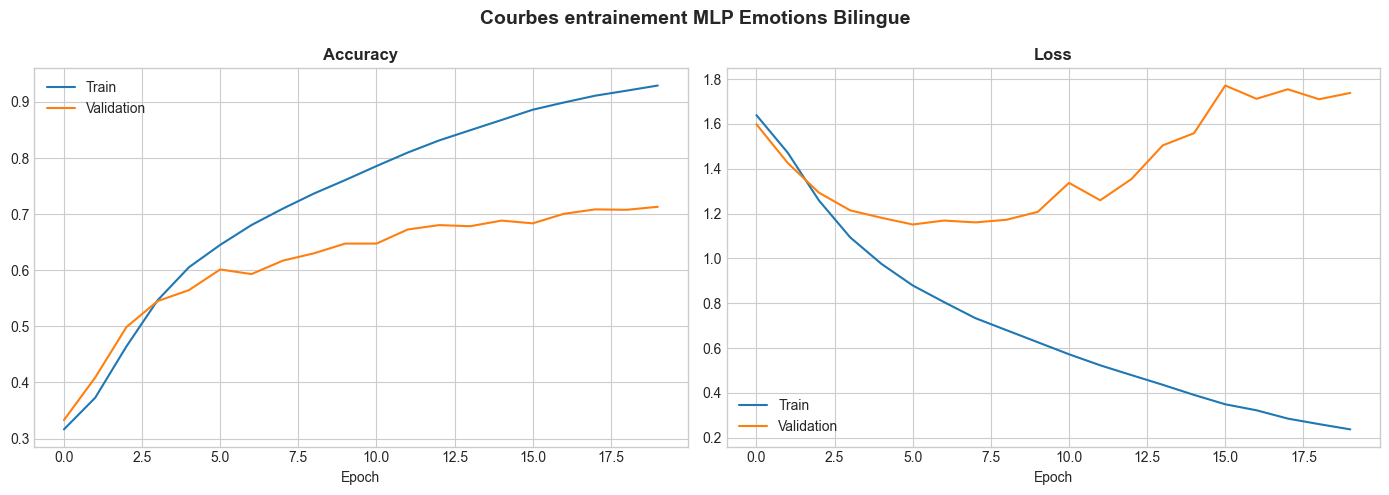

In [6]:
# Courbes d'entrainement
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_acc'], label='Train')
axes[0].plot(history['val_acc'], label='Validation')
axes[0].set_title('Accuracy', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history['train_loss'], label='Train')
axes[1].plot(history['val_loss'], label='Validation')
axes[1].set_title('Loss', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.suptitle('Courbes entrainement MLP Emotions Bilingue', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## PARTIE 4 — Evaluation sur le jeu de test

METRIQUES GLOBALES (test set bilingue)

              precision    recall  f1-score   support

      colere       0.68      0.71      0.69       575
      degout       0.75      0.76      0.75       300
        joie       0.86      0.90      0.88      1154
      neutre       0.67      0.66      0.67       300
        peur       0.63      0.59      0.61       524
    surprise       0.42      0.50      0.46       366
   tristesse       0.73      0.64      0.68       881

    accuracy                           0.71      4100
   macro avg       0.68      0.68      0.68      4100
weighted avg       0.72      0.71      0.71      4100

F1 macro:    0.6779
F1 weighted: 0.7149


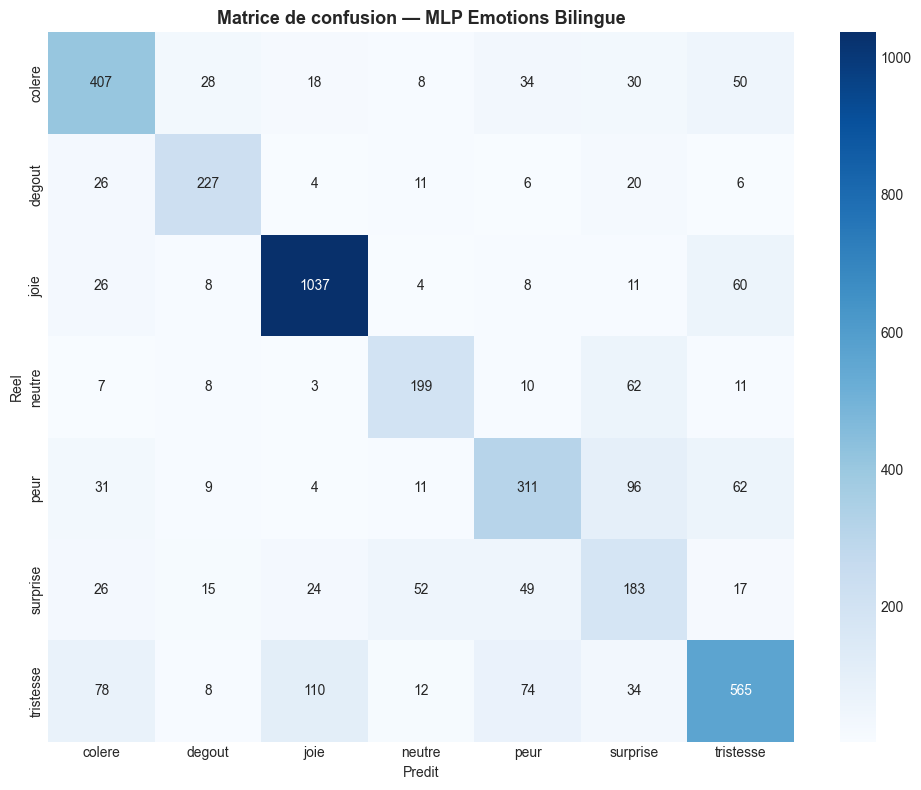

In [7]:
# Prediction sur le test set
model.eval()
all_logits = []
with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        logits = model(X_batch)
        all_logits.append(logits.cpu())

all_logits = torch.cat(all_logits, dim=0)
y_proba = torch.softmax(all_logits, dim=1).numpy()
y_pred = np.argmax(y_proba, axis=1)

# === Metriques globales ===
print('=' * 60)
print('METRIQUES GLOBALES (test set bilingue)')
print('=' * 60)
print()
print(classification_report(y_test, y_pred, target_names=LABEL_ORDER))

f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')
print(f'F1 macro:    {f1_macro:.4f}')
print(f'F1 weighted: {f1_weighted:.4f}')

# === Matrice de confusion ===
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABEL_ORDER, yticklabels=LABEL_ORDER, ax=ax)
ax.set_xlabel('Predit')
ax.set_ylabel('Reel')
ax.set_title('Matrice de confusion — MLP Emotions Bilingue', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# === Metriques par langue ===
print('=' * 60)
print('METRIQUES PAR LANGUE')
print('=' * 60)

all_labels = list(range(len(LABEL_ORDER)))

for lang in ['en', 'fr']:
    mask = df_test['language'] == lang
    y_t = y_test[mask.values]
    y_p = y_pred[mask.values]

    f1_m = f1_score(y_t, y_p, average='macro', labels=all_labels, zero_division=0)
    f1_w = f1_score(y_t, y_p, average='weighted', labels=all_labels, zero_division=0)

    print(f'\n  [{lang.upper()}] ({mask.sum()} textes)')
    print(f'    F1 macro:    {f1_m:.4f}')
    print(f'    F1 weighted: {f1_w:.4f}')

    # F1 par classe pour cette langue
    report = classification_report(y_t, y_p, labels=all_labels, target_names=LABEL_ORDER, output_dict=True, zero_division=0)
    for cls in LABEL_ORDER:
        f1_cls = report[cls]['f1-score']
        support = report[cls]['support']
        marker = ' (FR-only)' if cls in ('degout', 'neutre') and lang == 'en' else ''
        if support > 0:
            print(f'    {cls:12s}: F1={f1_cls:.3f} (n={support}){marker}')
        else:
            print(f'    {cls:12s}: pas de donnees EN{marker}')

METRIQUES PAR LANGUE

  [EN] (2000 textes)
    F1 macro:    0.5455
    F1 weighted: 0.8379
    colere      : F1=0.767 (n=275.0)
    degout      : pas de donnees EN (FR-only)
    joie        : F1=0.927 (n=854.0)
    neutre      : pas de donnees EN (FR-only)
    peur        : F1=0.758 (n=224.0)
    surprise    : F1=0.565 (n=66.0)
    tristesse   : F1=0.803 (n=581.0)

  [FR] (2100 textes)
    F1 macro:    0.5943
    F1 weighted: 0.5943
    colere      : F1=0.628 (n=300.0)
    degout      : F1=0.753 (n=300.0)
    joie        : F1=0.750 (n=300.0)
    neutre      : F1=0.669 (n=300.0)
    peur        : F1=0.491 (n=300.0)
    surprise    : F1=0.437 (n=300.0)
    tristesse   : F1=0.433 (n=300.0)


---
## PARTIE 5 — Sanity check : phrases manuelles FR et EN

In [9]:
def predict_proba(texts):
    """Predit les probabilites d'emotion pour une liste de textes.
    Contrat d'interface Phase 2: retourne array (n, 7).
    """
    seqs = texts_to_sequences(texts, vocab, MAX_LENGTH)
    X = torch.from_numpy(seqs).to(device)
    model.eval()
    with torch.no_grad():
        logits = model(X)
        probas = torch.softmax(logits, dim=1).cpu().numpy()
    return probas

# Phrases de test manuelles
sanity_texts = [
    # FR
    ("Je suis tellement heureux d'avoir reussi mon examen !", 'joie', 'FR'),
    ("Cette injustice me met hors de moi, c'est inadmissible.", 'colere', 'FR'),
    ("Mon grand-pere nous a quittes hier, il va me manquer.", 'tristesse', 'FR'),
    ("Le rapport trimestriel sera disponible lundi prochain.", 'neutre', 'FR'),
    ("J'ai entendu un bruit etrange dans la maison, je suis terrifiee.", 'peur', 'FR'),
    # EN
    ("I just got promoted at work, this is the best day ever!", 'joie', 'EN'),
    ("I am absolutely furious about this unfair treatment.", 'colere', 'EN'),
    ("Losing my best friend was the hardest thing I've been through.", 'tristesse', 'EN'),
    ("I can't believe they actually won the championship!", 'surprise', 'EN'),
    ("Walking alone in the dark alley made me extremely anxious.", 'peur', 'EN'),
]

sanity_txts = [t[0] for t in sanity_texts]
sanity_expected = [t[1] for t in sanity_texts]
sanity_langs = [t[2] for t in sanity_texts]

probas = predict_proba(sanity_txts)
preds = le.inverse_transform(np.argmax(probas, axis=1))

print('=' * 70)
print('SANITY CHECK : PHRASES MANUELLES FR + EN')
print('=' * 70)
print()

ok_count = 0
for txt, expected, lang, pred, proba in zip(sanity_txts, sanity_expected, sanity_langs, preds, probas):
    status = ' OK ' if pred == expected else 'FAIL'
    if pred == expected:
        ok_count += 1

    # Top 3 probas
    top3_idx = np.argsort(proba)[::-1][:3]
    top3 = [(le.inverse_transform([i])[0], proba[i]) for i in top3_idx]
    top3_str = ', '.join(f'{name}:{p:.2f}' for name, p in top3)

    print(f'  [{status}] [{lang}] Attendu={expected:10s} | Predit={pred:10s} | Top3: {top3_str}')
    print(f'         {txt[:75]}')
    print()

print(f'Resultat : {ok_count}/{len(sanity_texts)} corrects')

SANITY CHECK : PHRASES MANUELLES FR + EN

  [ OK ] [FR] Attendu=joie       | Predit=joie       | Top3: joie:1.00, tristesse:0.00, peur:0.00
         Je suis tellement heureux d'avoir reussi mon examen !

  [FAIL] [FR] Attendu=colere     | Predit=joie       | Top3: joie:0.75, tristesse:0.17, colere:0.08
         Cette injustice me met hors de moi, c'est inadmissible.

  [FAIL] [FR] Attendu=tristesse  | Predit=surprise   | Top3: surprise:0.53, peur:0.25, colere:0.14
         Mon grand-pere nous a quittes hier, il va me manquer.

  [ OK ] [FR] Attendu=neutre     | Predit=neutre     | Top3: neutre:0.88, surprise:0.10, degout:0.02
         Le rapport trimestriel sera disponible lundi prochain.

  [FAIL] [FR] Attendu=peur       | Predit=surprise   | Top3: surprise:0.60, peur:0.31, colere:0.05
         J'ai entendu un bruit etrange dans la maison, je suis terrifiee.

  [FAIL] [EN] Attendu=joie       | Predit=tristesse  | Top3: tristesse:0.42, peur:0.19, colere:0.18
         I just got promote

---
## PARTIE 6 — Sauvegarde du modele bilingue

In [10]:
os.makedirs('../models', exist_ok=True)

# Modele PyTorch
torch.save(model.state_dict(), '../models/emotion_bilingual.pt')

# Vocabulaire (equivalent tokenizer)
with open('../models/emotion_vocab_bilingual.pickle', 'wb') as f:
    pickle.dump(vocab, f, protocol=pickle.HIGHEST_PROTOCOL)

# Label encoder
with open('../models/emotion_label_encoder_bilingual.pickle', 'wb') as f:
    pickle.dump(le, f, protocol=pickle.HIGHEST_PROTOCOL)

print('Modele bilingue sauvegarde dans /models/ :')
print('  - emotion_bilingual.pt')
print('  - emotion_vocab_bilingual.pickle')
print('  - emotion_label_encoder_bilingual.pickle')
print()
print(f'Contrat interface : predict_proba(texts) -> array shape (n, 7)')
print(f'Classes : {list(le.classes_)}')
print(f'Exemple : predict_proba(["text"])[0] = {probas[0].round(3)}')

Modele bilingue sauvegarde dans /models/ :
  - emotion_bilingual.pt
  - emotion_vocab_bilingual.pickle
  - emotion_label_encoder_bilingual.pickle

Contrat interface : predict_proba(texts) -> array shape (n, 7)
Classes : [np.str_('colere'), np.str_('degout'), np.str_('joie'), np.str_('neutre'), np.str_('peur'), np.str_('surprise'), np.str_('tristesse')]
Exemple : predict_proba(["text"])[0] = [0.    0.    0.995 0.    0.    0.    0.005]


---
## PARTIE 7 — Application sur les posts Bluesky (si MongoDB disponible)

In [11]:
try:
    from pymongo import MongoClient, UpdateOne
    client = MongoClient('mongodb://mongodb:27017/', serverSelectionTimeoutMS=3000)
    client.server_info()
    collection = client['thumalien_db']['raw_posts']

    cursor = collection.find({}, {'_id': 0, 'uri': 1, 'text': 1})
    df_bluesky = pd.DataFrame(list(cursor))
    print(f'Posts Bluesky charges : {len(df_bluesky)}')

    if not df_bluesky.empty:
        bs_probas = predict_proba(df_bluesky['text'].astype(str).values)
        bs_preds = le.inverse_transform(np.argmax(bs_probas, axis=1))
        df_bluesky['ai_emotion'] = bs_preds

        print(f'\nDistribution des emotions :')
        print(df_bluesky['ai_emotion'].value_counts())

        ops = []
        for _, row in df_bluesky.iterrows():
            ops.append(UpdateOne(
                {'uri': row['uri']},
                {'$set': {'ai_emotion': row['ai_emotion'],
                          'ai_emotion_model': 'emotion_bilingual_v2'}},
            ))
        collection.bulk_write(ops)
        print(f'{len(ops)} posts mis a jour.')

except Exception as e:
    print(f'MongoDB non disponible: {e}')
    print('Le modele est sauvegarde et pret pour inference.')

MongoDB non disponible: mongodb:27017: [Errno 8] nodename nor servname provided, or not known (configured timeouts: socketTimeoutMS: 20000.0ms, connectTimeoutMS: 20000.0ms), Timeout: 3.0s, Topology Description: <TopologyDescription id: 698e48e27dca02fbf832ae23, topology_type: Unknown, servers: [<ServerDescription ('mongodb', 27017) server_type: Unknown, rtt: None, error=AutoReconnect('mongodb:27017: [Errno 8] nodename nor servname provided, or not known (configured timeouts: socketTimeoutMS: 20000.0ms, connectTimeoutMS: 20000.0ms)')>]>
Le modele est sauvegarde et pret pour inference.


In [12]:
# Resume final
print()
print('=' * 60)
print('RESUME DU MODELE EMOTIONS BILINGUE')
print('=' * 60)
print()
print(f'Framework        : PyTorch {torch.__version__}')
print(f'Architecture     : Embedding(25K,64) + GAP + Dense(48) + Dense(24) + Dense(7)')
print(f'Classes          : {list(le.classes_)}')
print(f'Dataset train    : {len(df_train)} textes (EN: {(df_train["language"]=="en").sum()}, FR: {(df_train["language"]=="fr").sum()})')
print(f'Dataset test     : {len(df_test)} textes (EN: {(df_test["language"]=="en").sum()}, FR: {(df_test["language"]=="fr").sum()})')
print(f'F1 macro (test)  : {f1_macro:.4f}')
print(f'F1 weighted      : {f1_weighted:.4f}')
print(f'Seuil Phase 2    : F1 macro > 0.50 -> {"OK" if f1_macro > 0.50 else "INSUFFISANT"}')
print(f'predict_proba    : predict_proba(texts) -> (n, 7) probabilites')
print(f'Fichiers         : emotion_bilingual.pt + vocab + label_encoder')


RESUME DU MODELE EMOTIONS BILINGUE

Framework        : PyTorch 2.10.0
Architecture     : Embedding(25K,64) + GAP + Dense(48) + Dense(24) + Dense(7)
Classes          : [np.str_('colere'), np.str_('degout'), np.str_('joie'), np.str_('neutre'), np.str_('peur'), np.str_('surprise'), np.str_('tristesse')]
Dataset train    : 25800 textes (EN: 16000, FR: 9800)
Dataset test     : 4100 textes (EN: 2000, FR: 2100)
F1 macro (test)  : 0.6779
F1 weighted      : 0.7149
Seuil Phase 2    : F1 macro > 0.50 -> OK
predict_proba    : predict_proba(texts) -> (n, 7) probabilites
Fichiers         : emotion_bilingual.pt + vocab + label_encoder
